In [20]:
from pathlib import Path
import pandas as pd
import numpy as np
import uproot
import matplotlib.pyplot as plt
import mplhep as hep
hep.style.use("CMS")

from llr_study import utils
from utils import functions

In [2]:
%config InlineBackend.figure_format = 'retina'

In [53]:
projectdir = Path('/eos/user/a/anunezde/Z_OUTPUT_eos/Disc_Study_New')
workdirs = ['LLR_odd', 'JetTop_even']
file_paths = [projectdir / wd / 'fits_new' / 'summary_results.txt' for wd in workdirs]
df = utils.parse_UL_results_files(file_paths)
df = df[df['obs_type'] != 'llr_from_multivar']
print(df['obs_type'].value_counts())


Total observables parsed: 147
var_1D               69
llr_from_1D          66
llr_from_multivar    12
Name: obs_type, dtype: int64
var_1D         69
llr_from_1D    66
Name: obs_type, dtype: int64


In [ ]:
# Only look at vars for which there are llrs
llr_names = df[df['obs_type'] == 'llr_from_1D']['obs_name'].values
var_names = [n.removesuffix('_llr') for n in llr_names]

In [ ]:
resultsdir = projectdir / 'JetTop_even' / 'results'
eras = functions.get_eras(resultsdir)
signal_files = functions.filter_files_by_process_and_era(resultsdir, ['ggHH_kl_1_kt_1_bbww'], eras)
bkg_files = functions.filter_files_by_process_and_era(resultsdir, ['ttbar','tW'], eras)

sig = utils.get_branch_as_df(signal_files, 'SL_4j_resolved', var_names)
bkg = utils.get_branch_as_df(bkg_files, 'SL_4j_resolved', var_names)

### Correlation matrices per class (Pearson and Spearman)

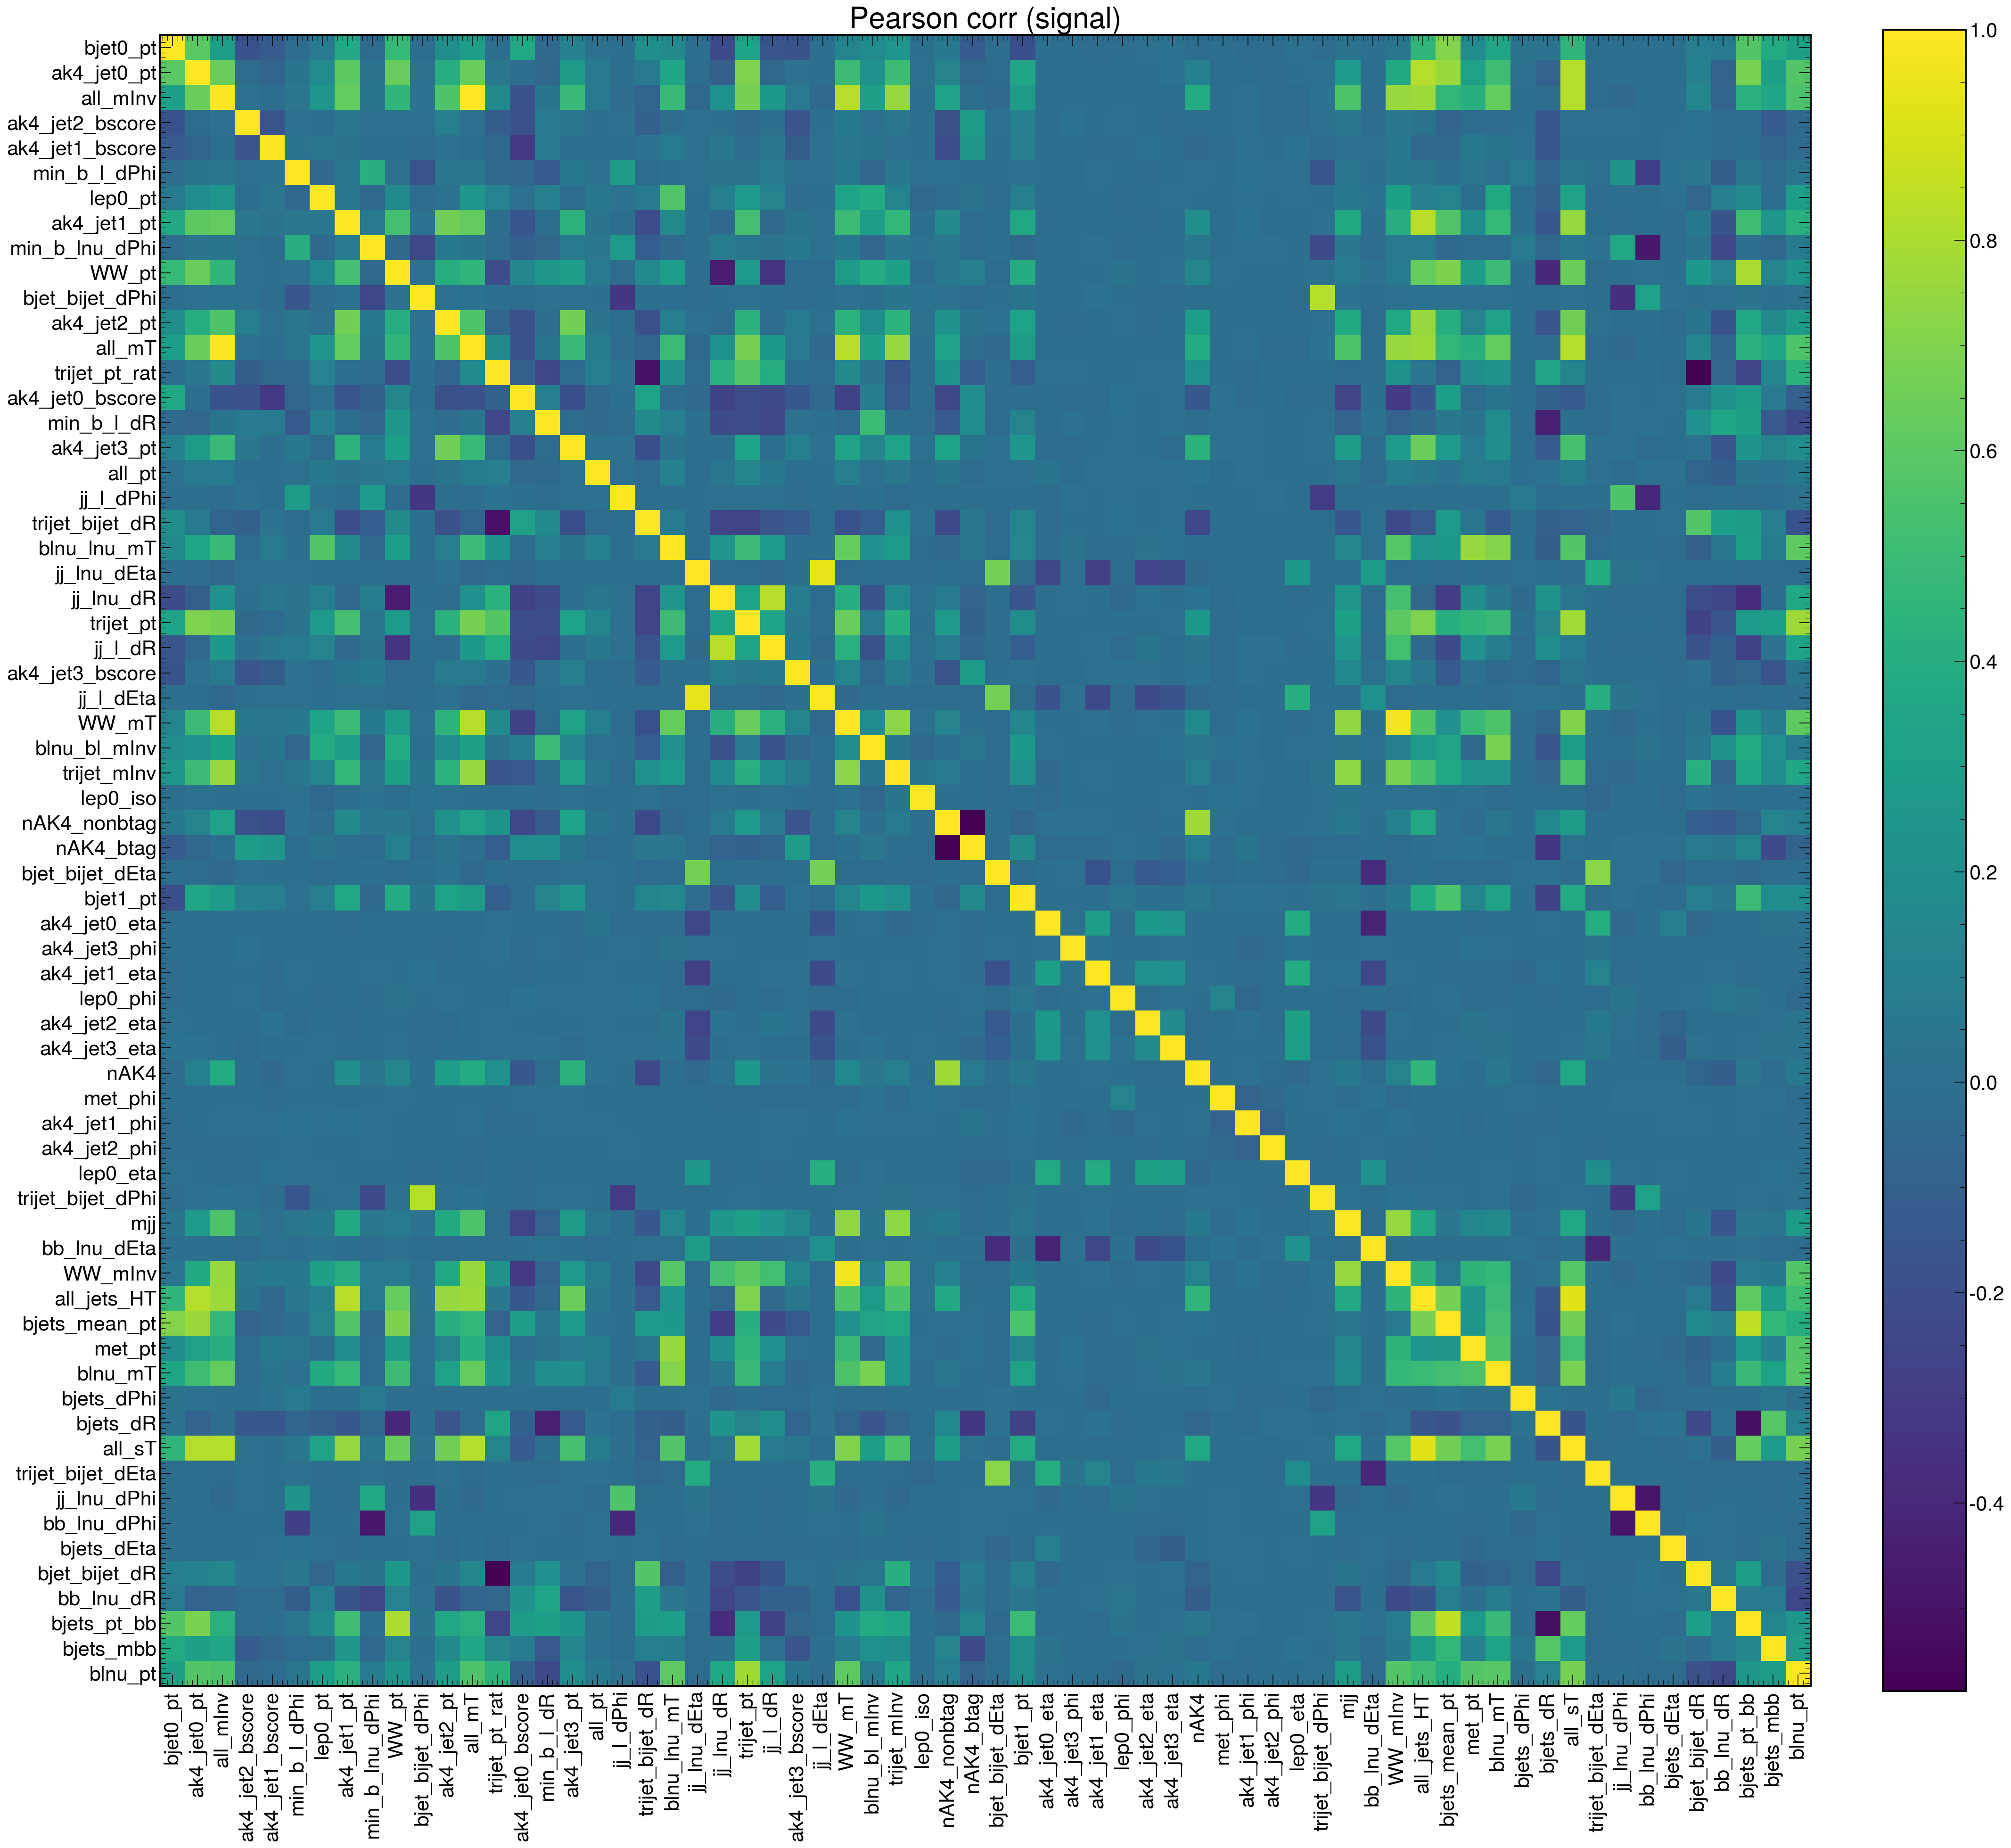

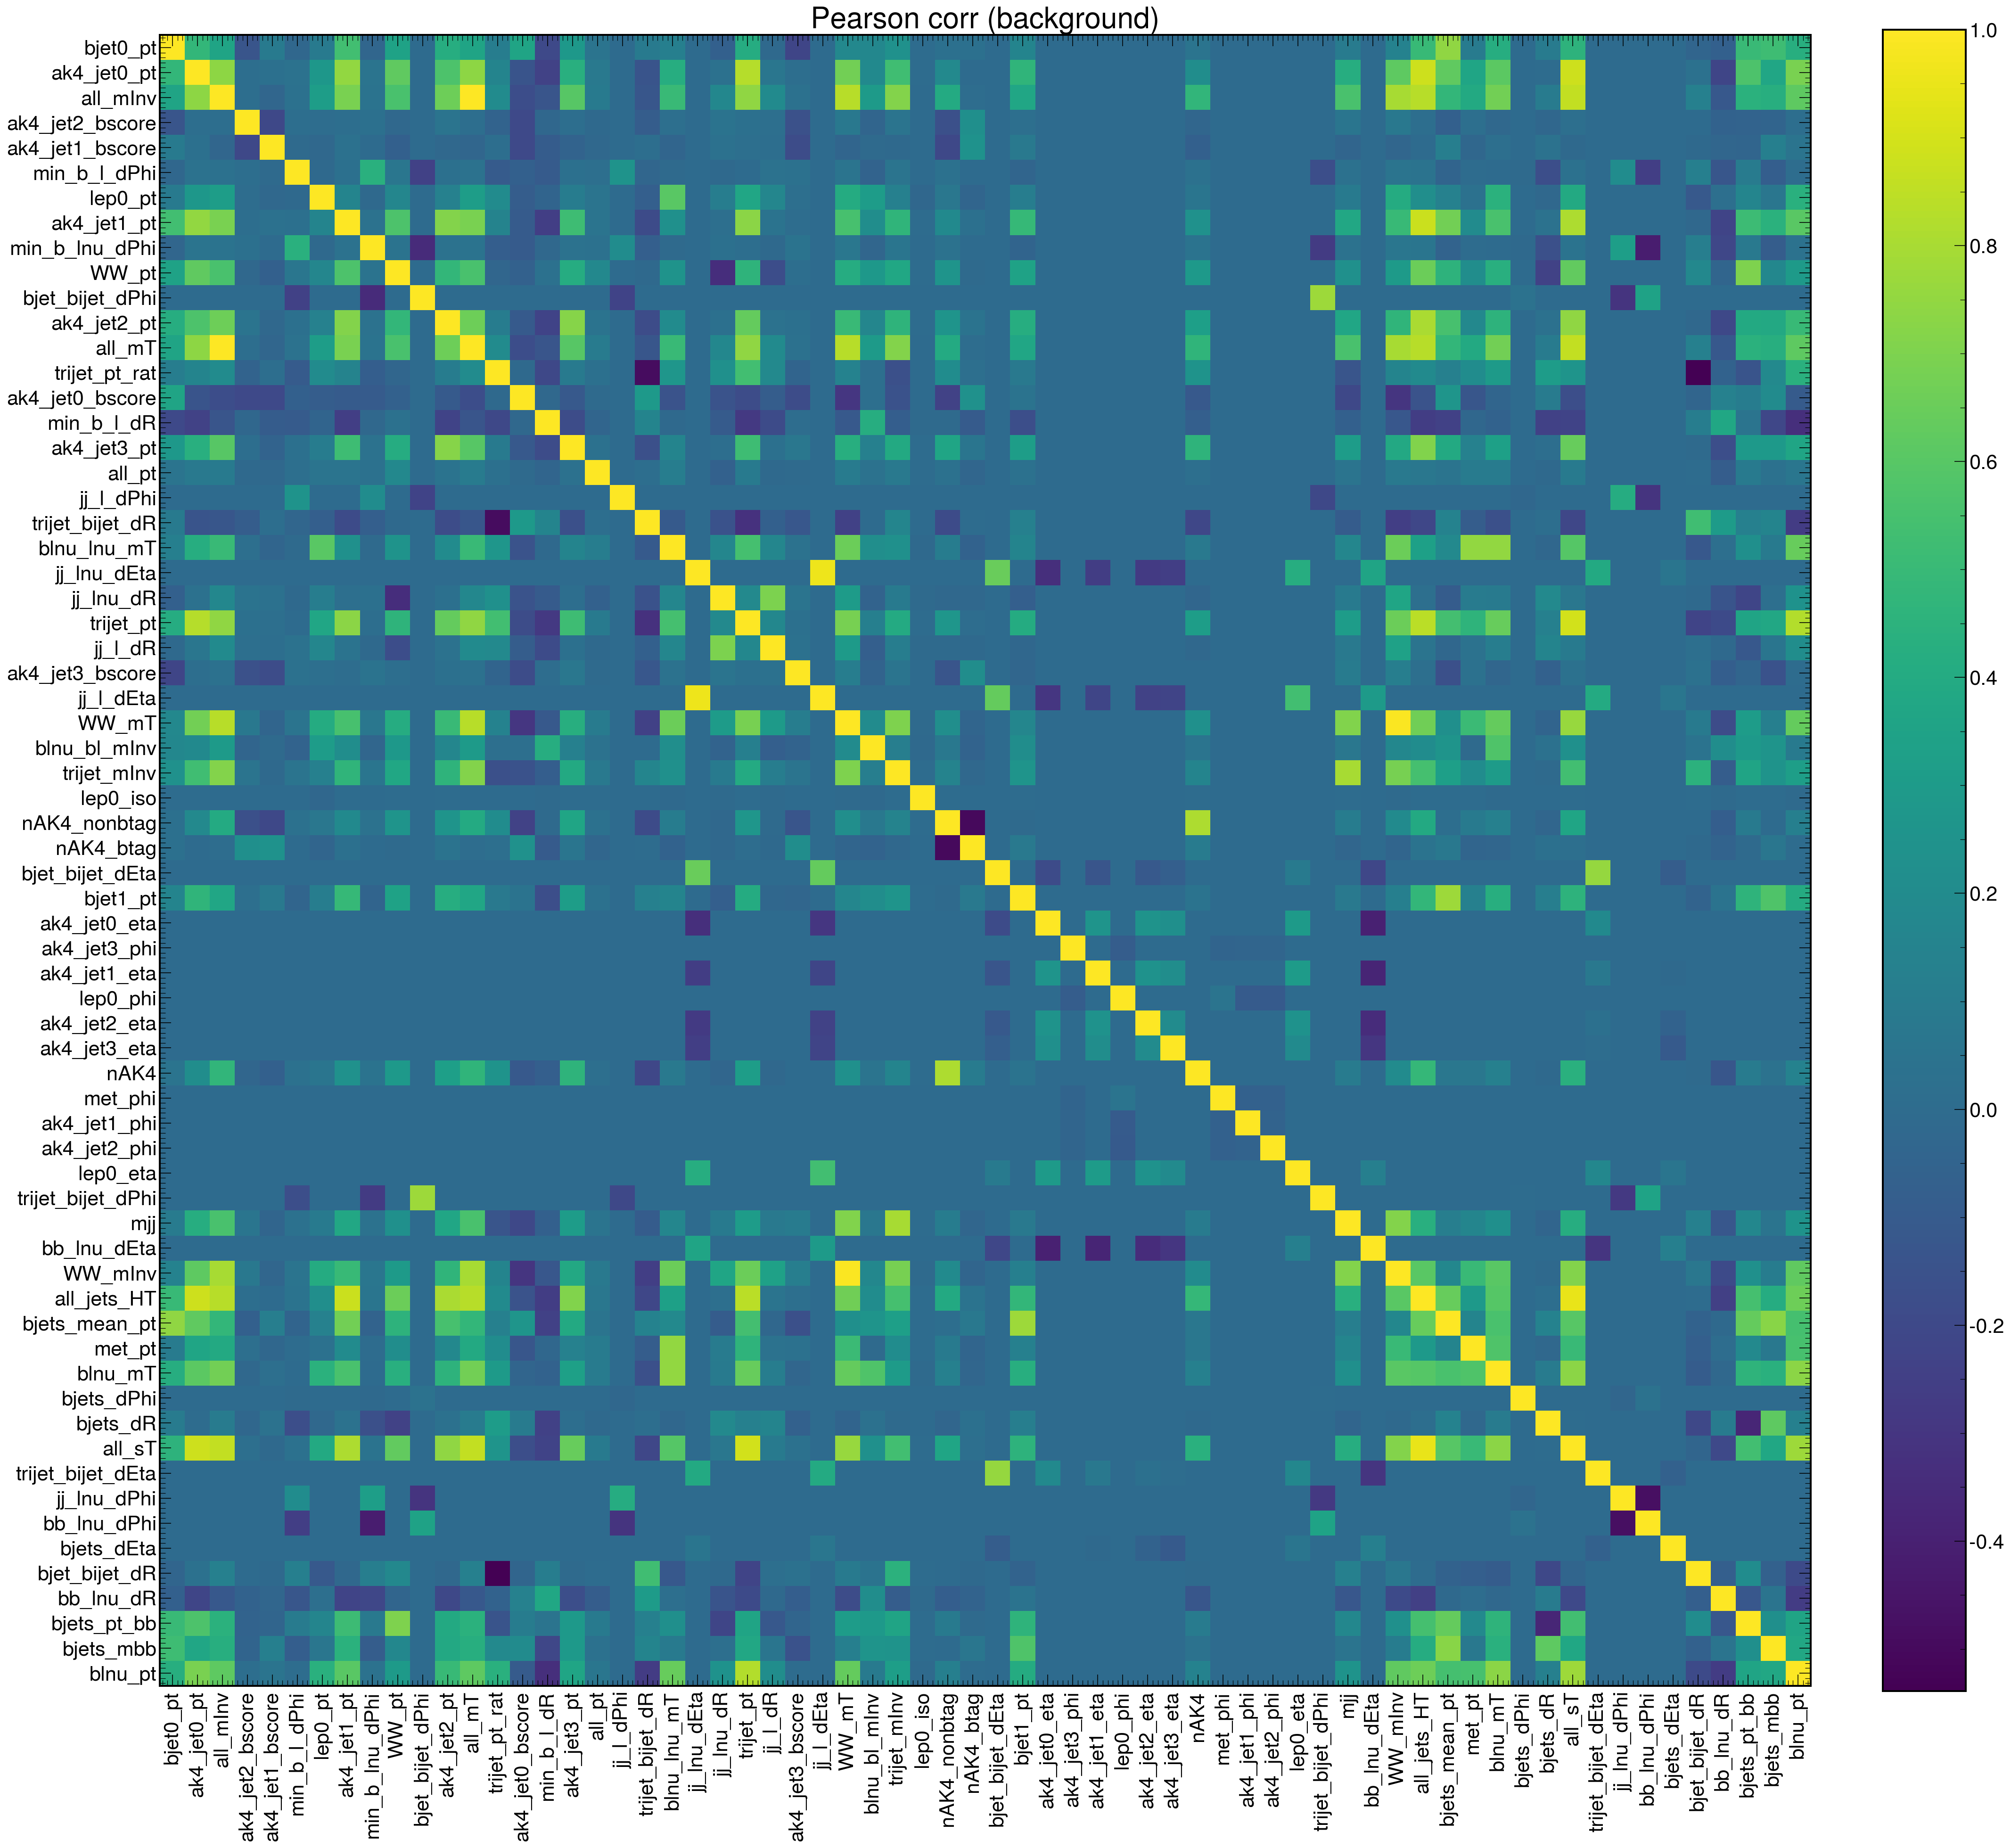

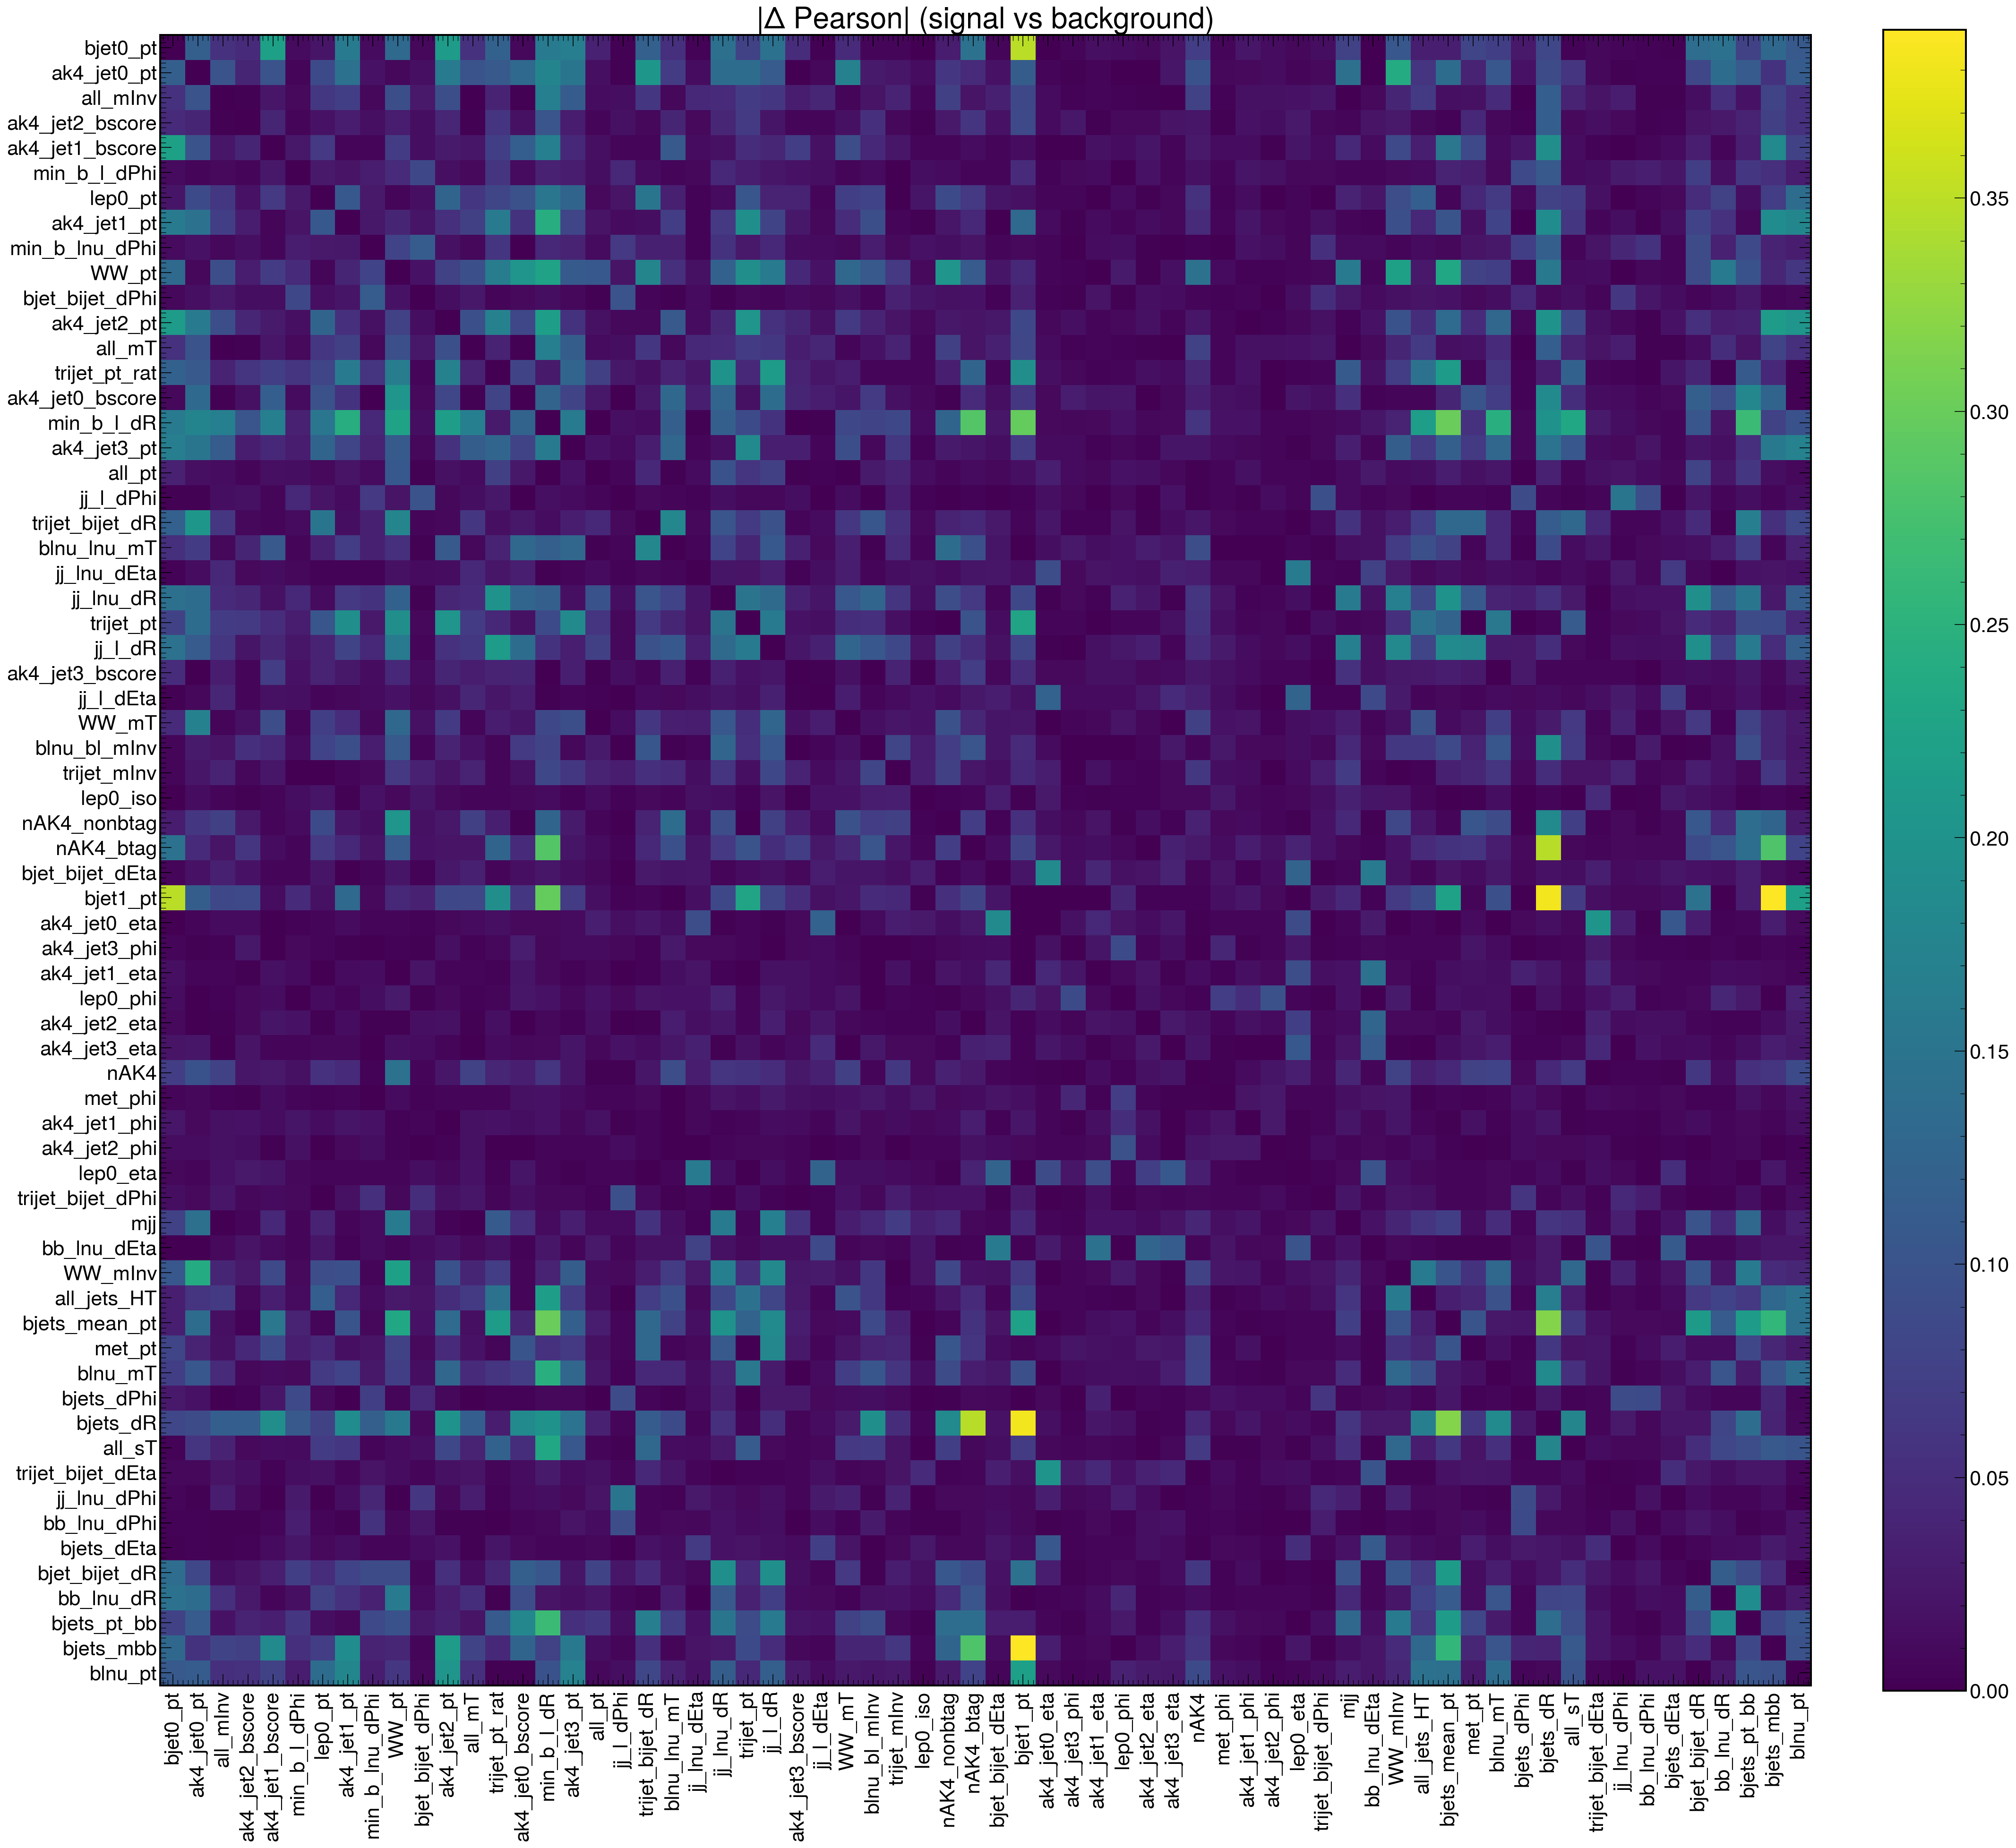

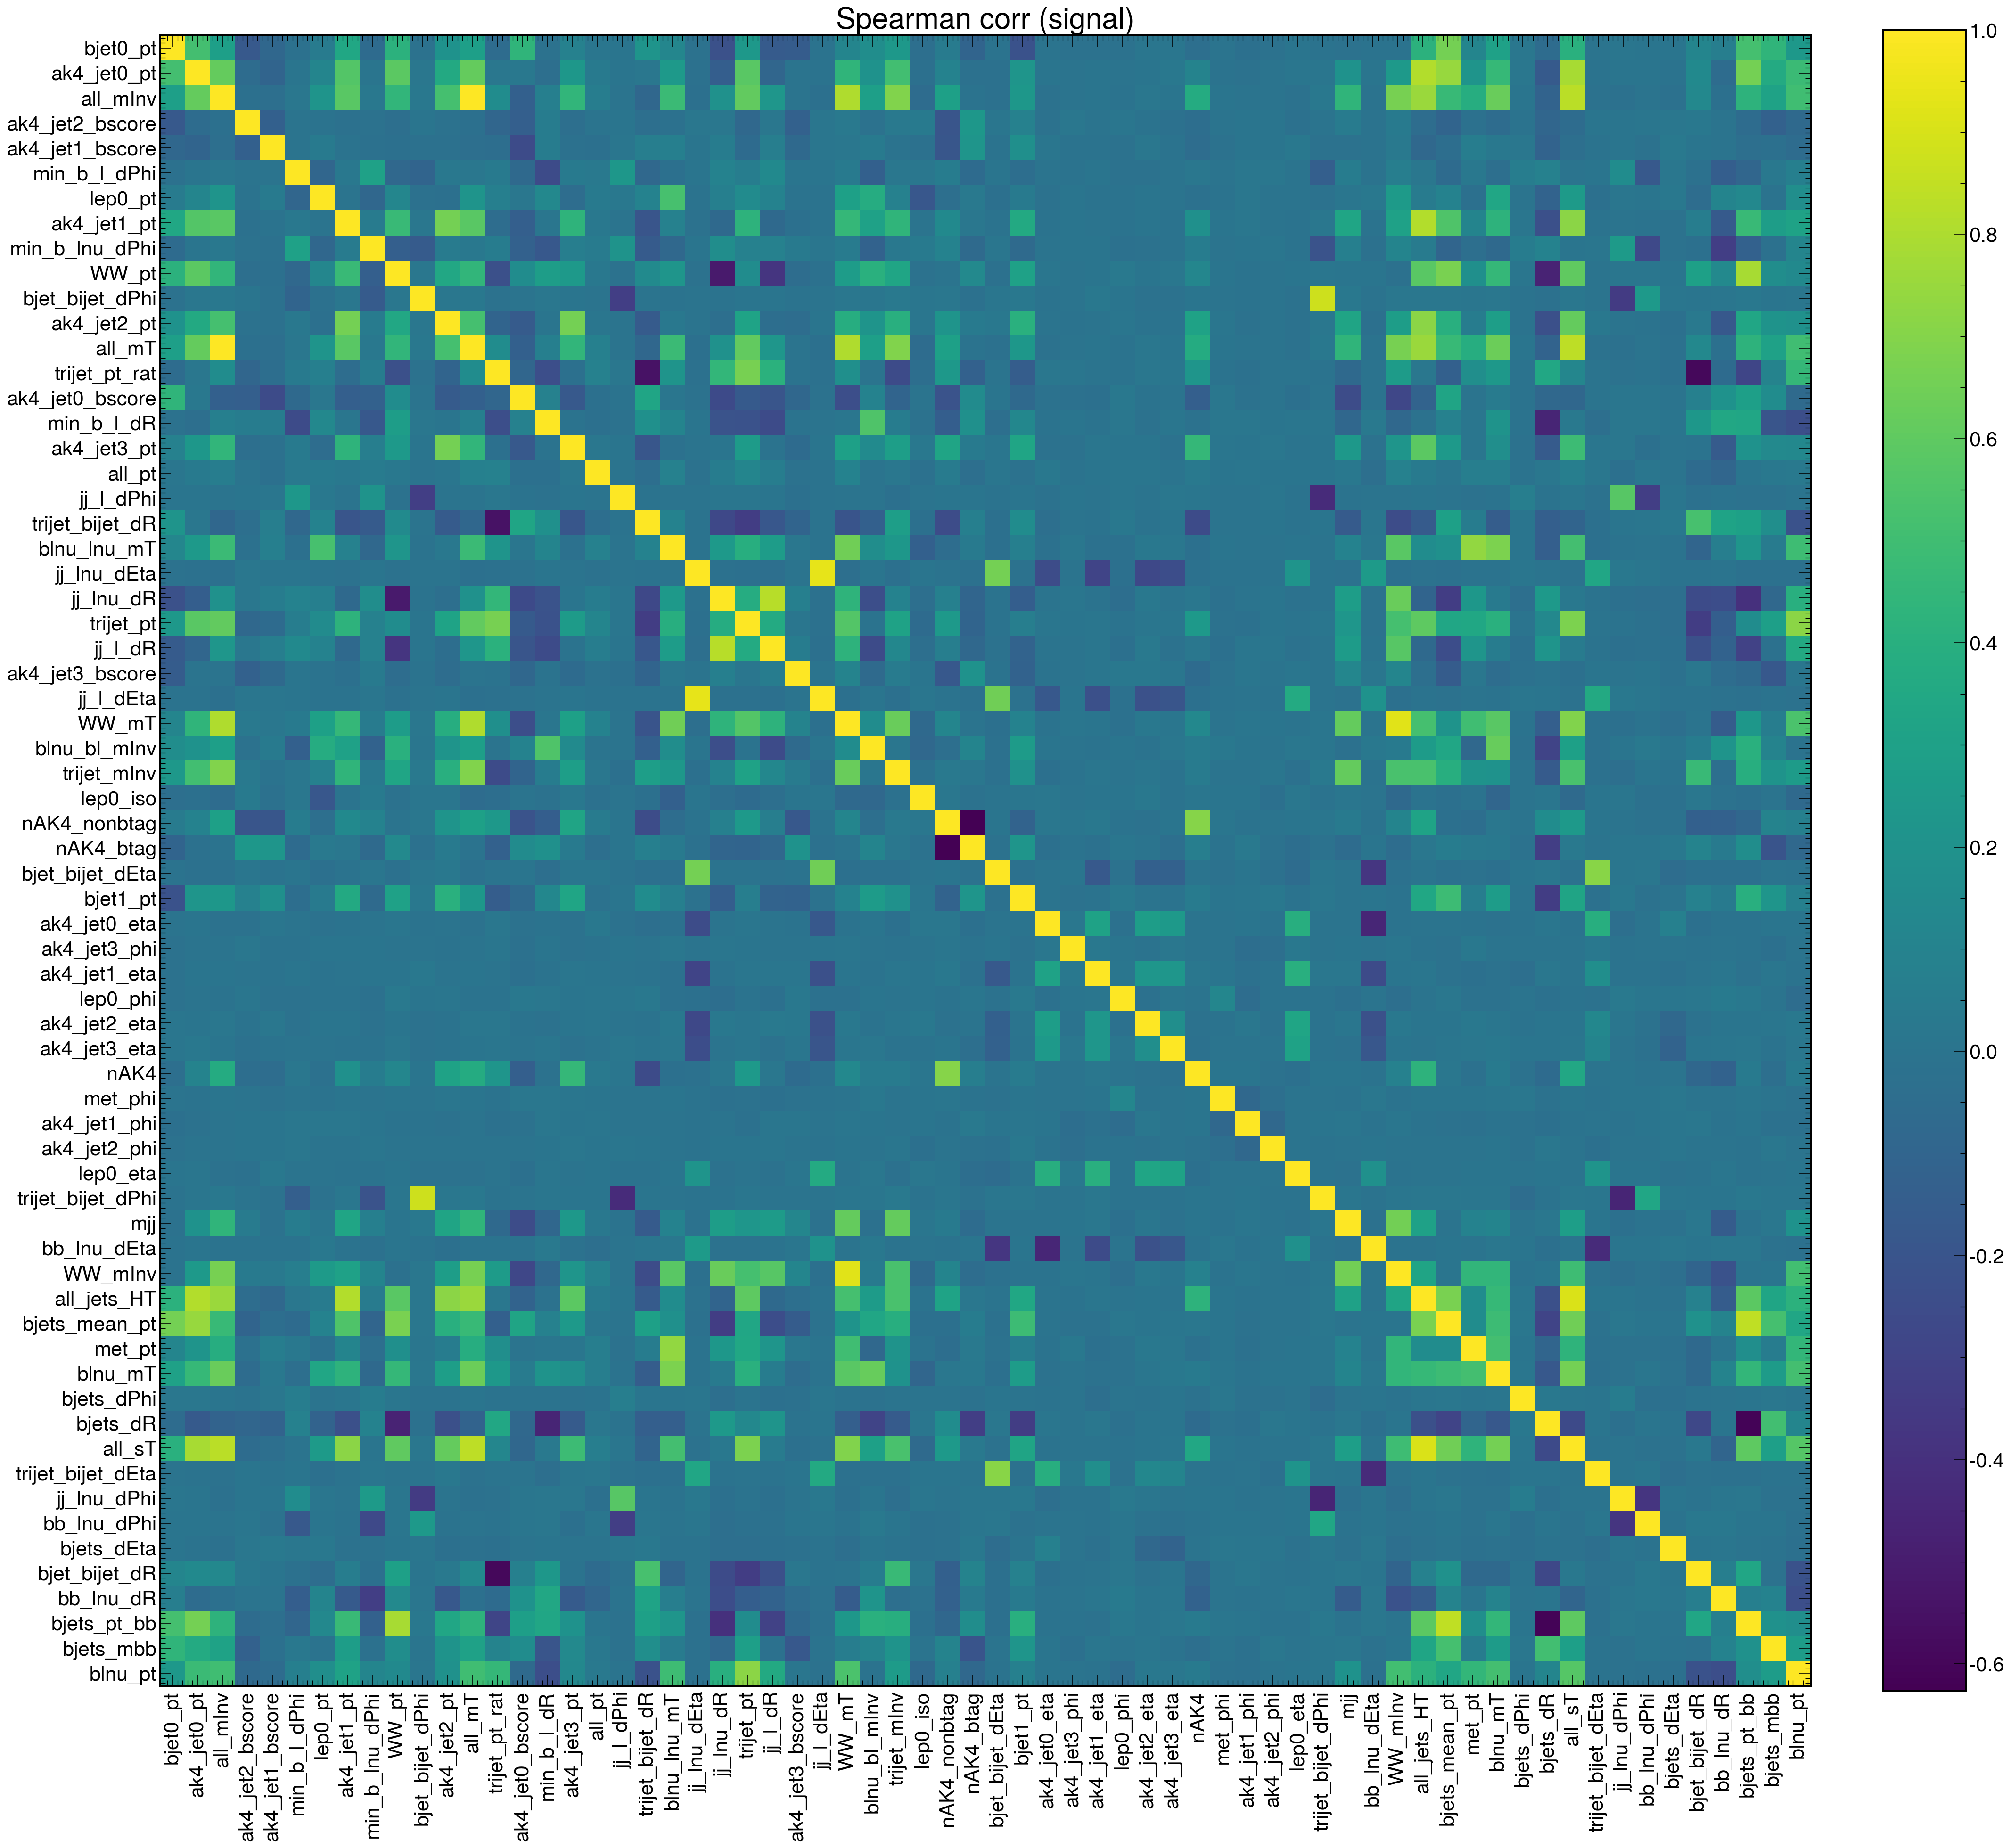

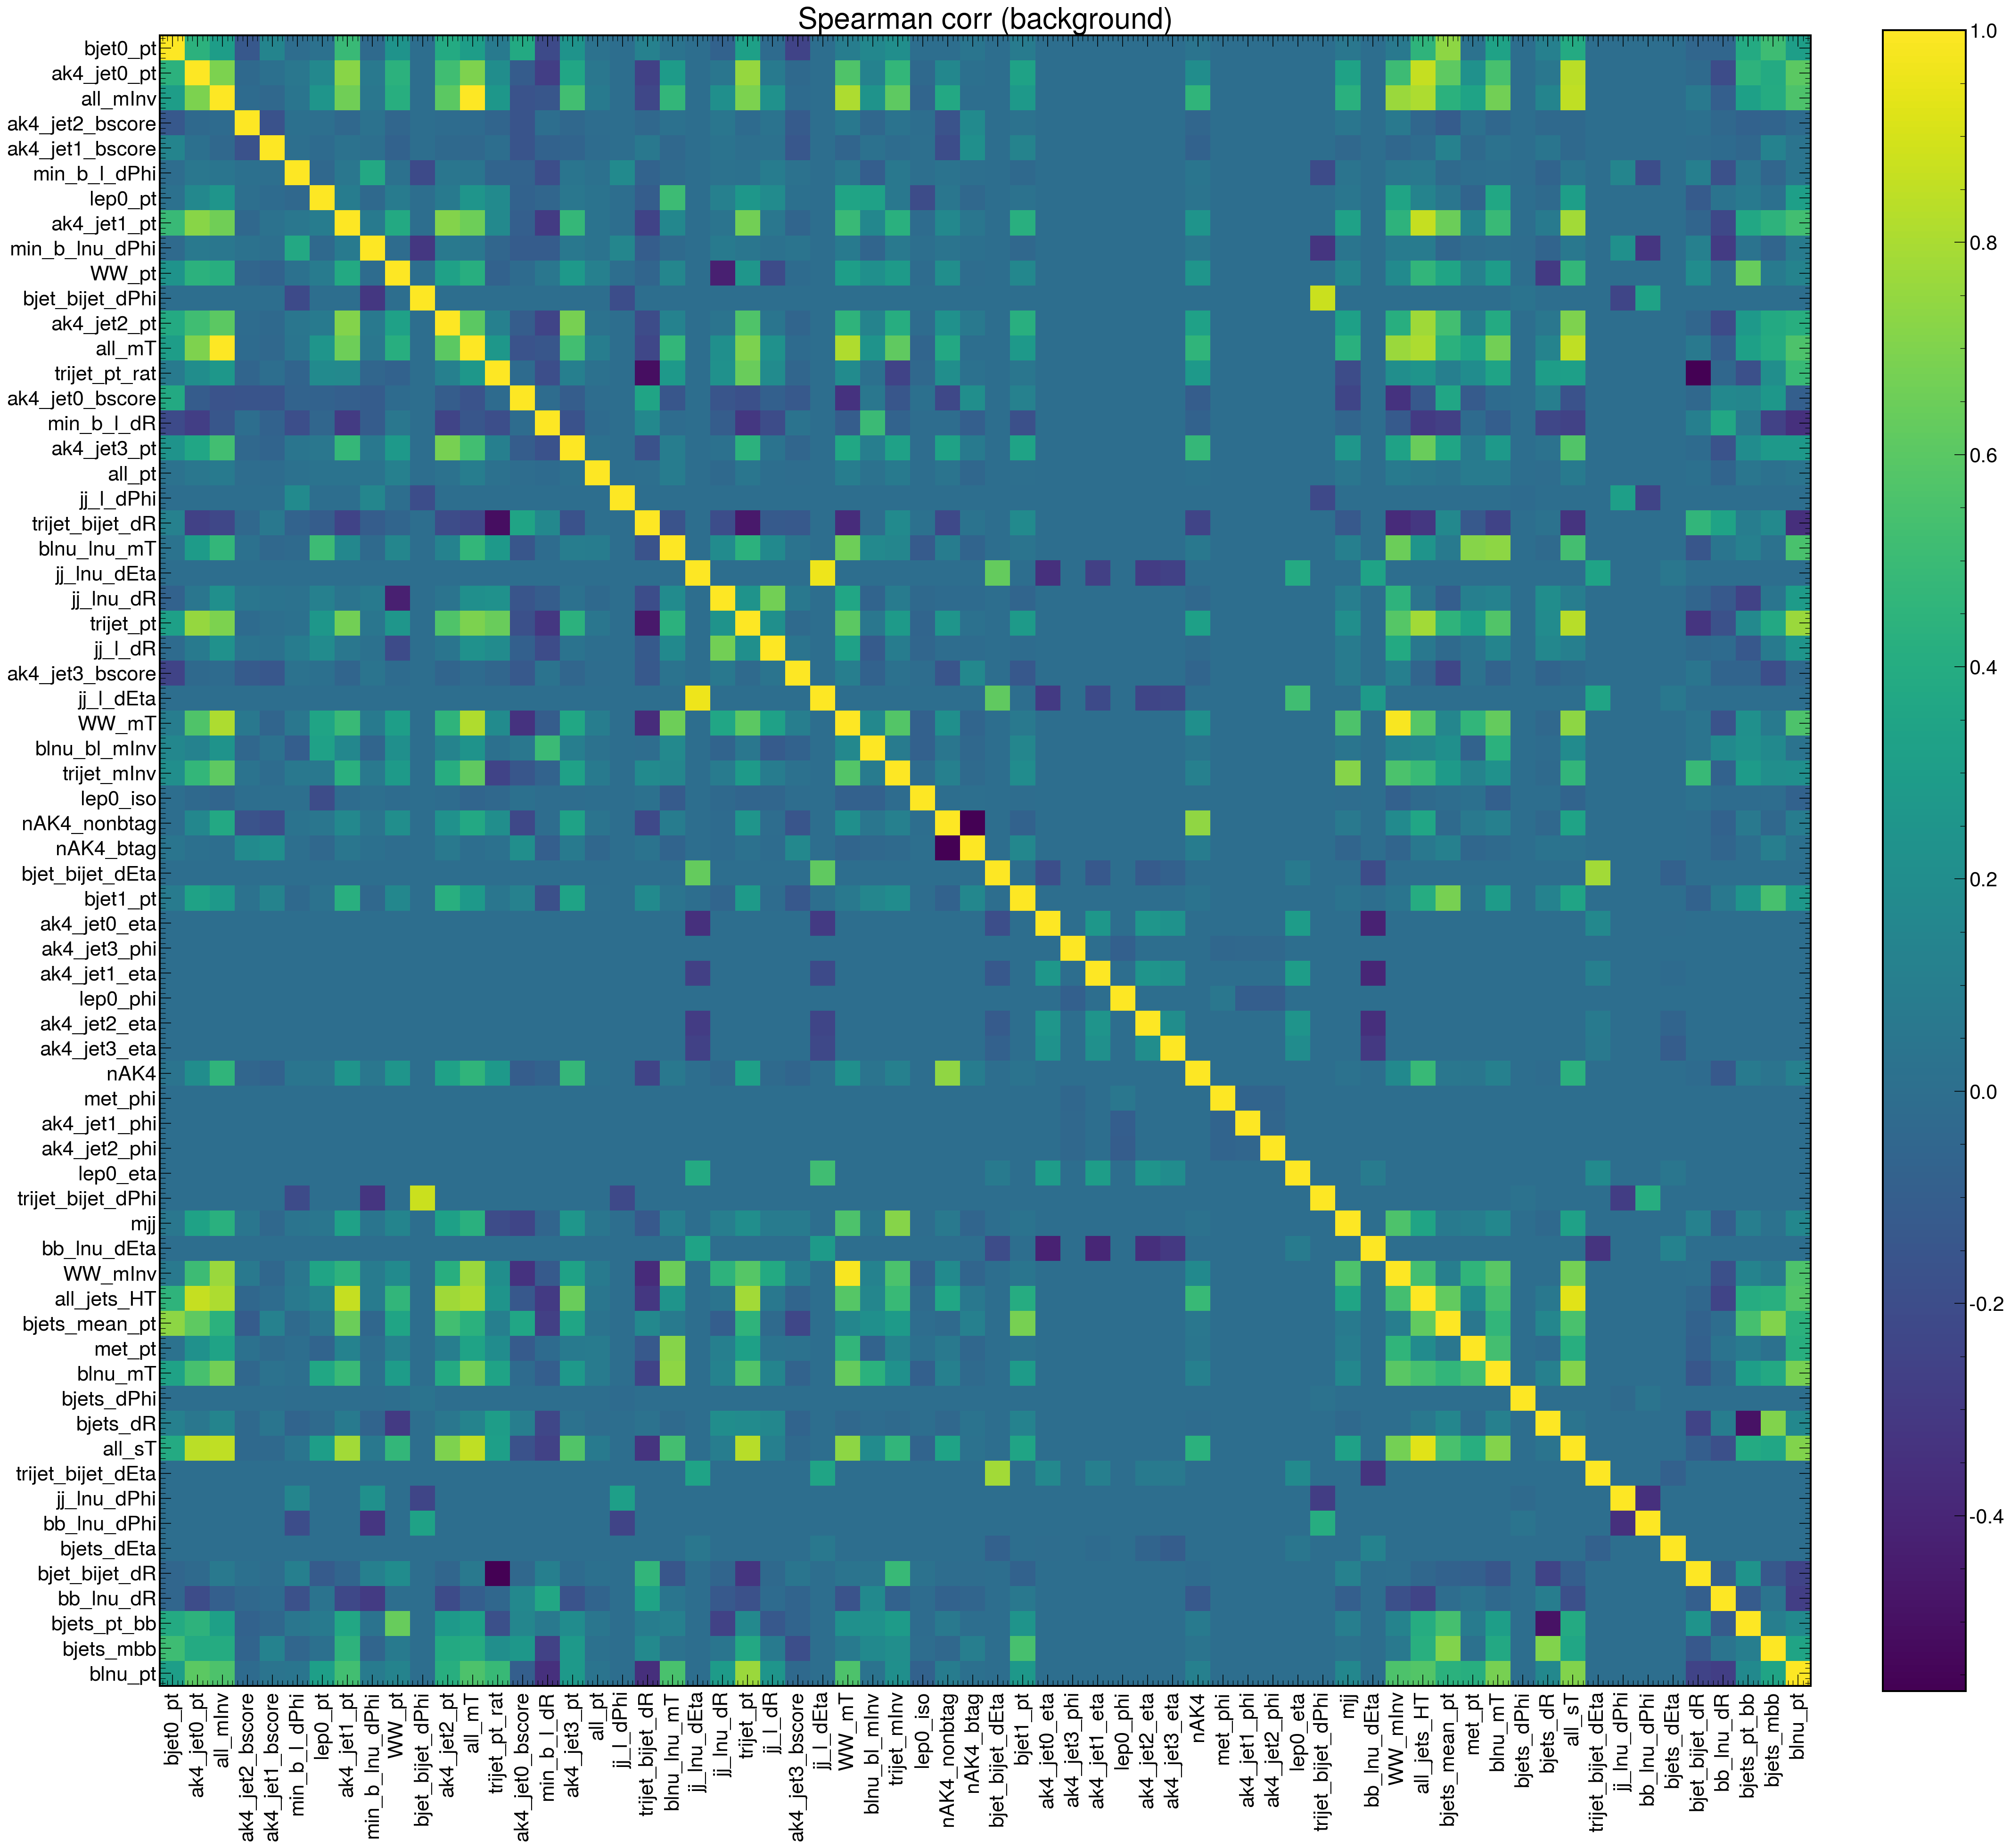

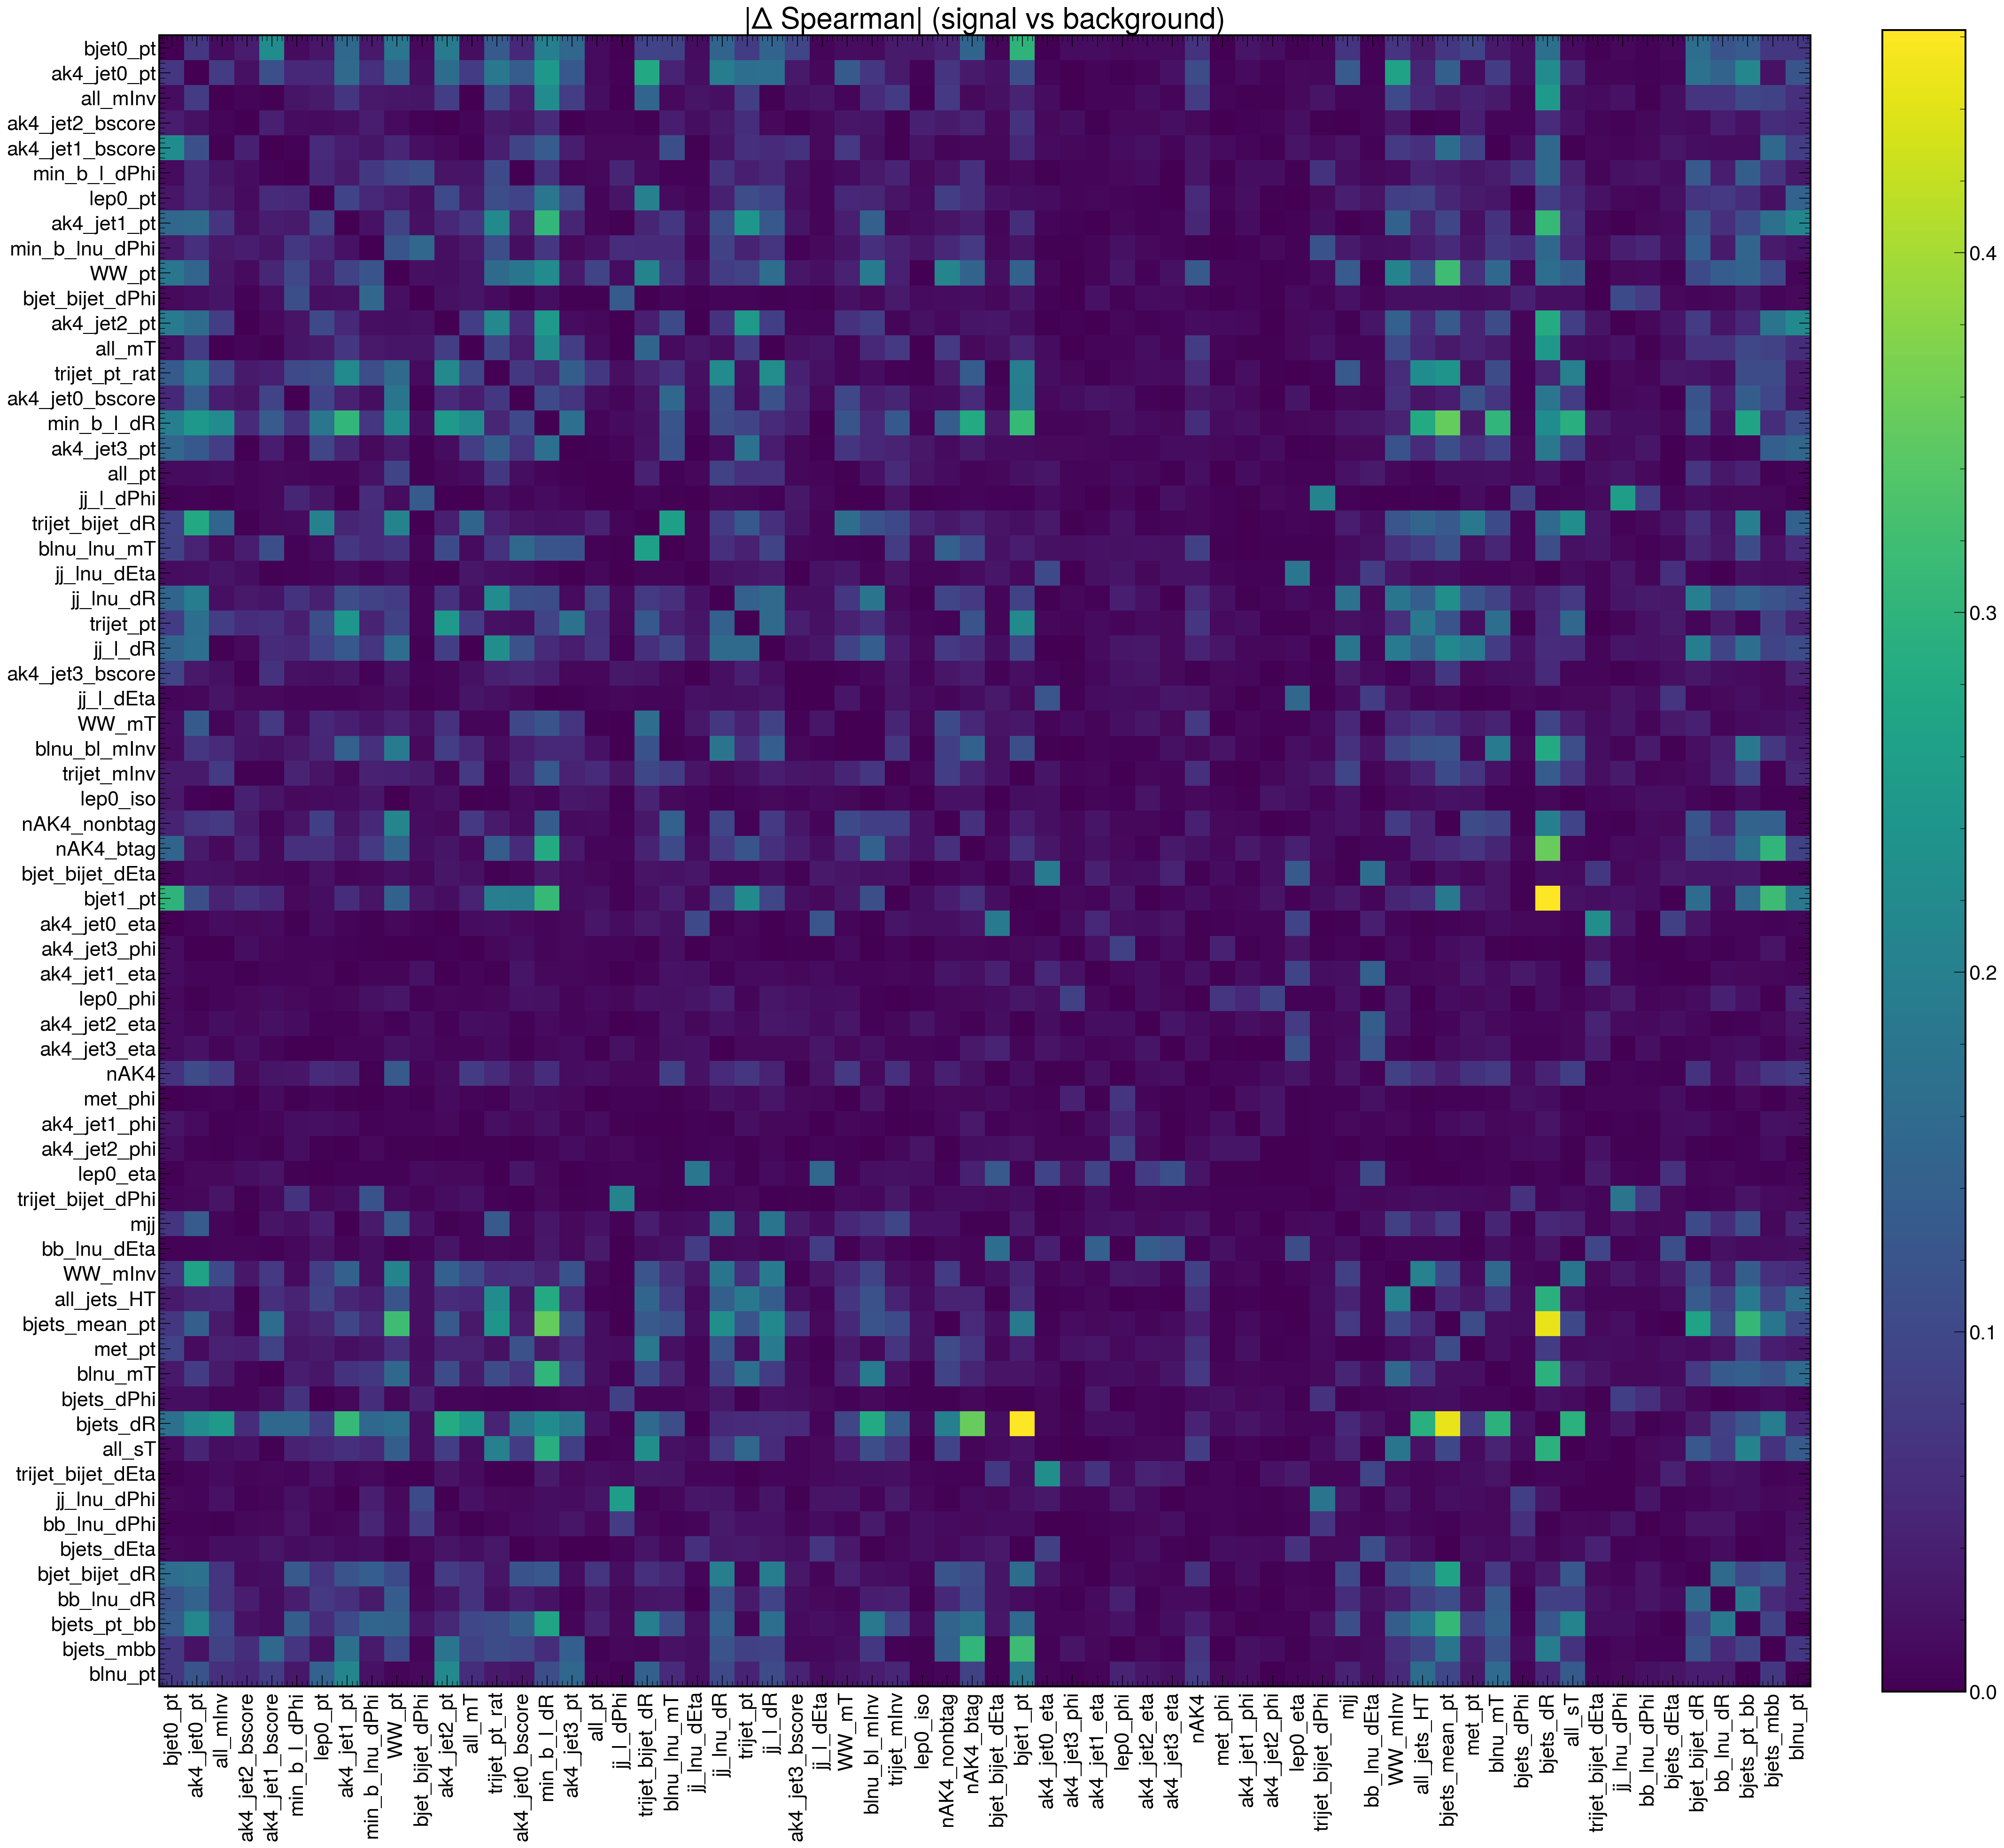

In [ ]:
feat = var_names  # the subset you want to test

corr_s_pear = sig[feat].corr(method='pearson')
corr_b_pear = bkg[feat].corr(method='pearson')
delta_pear = (corr_s_pear - corr_b_pear).abs()

corr_s_spear = sig[feat].corr(method='spearman')
corr_b_s_spear = bkg[feat].corr(method='spearman')
delta_spear = (corr_s_spear - corr_b_s_spear).abs()

# Heatmap (pure matplotlib)
def heatmap(mat, title):
    fig, ax = plt.subplots(figsize=(0.5+0.45*len(feat), 0.5+0.45*len(feat)))
    im = ax.imshow(mat.values, cmap='viridis')
    ax.set_xticks(range(len(feat))); ax.set_yticks(range(len(feat)))
    ax.set_xticklabels(feat, rotation=90); ax.set_yticklabels(feat)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    ax.set_title(title); plt.tight_layout()

heatmap(corr_s_pear, "Pearson corr (signal)")
heatmap(corr_b_pear, "Pearson corr (background)")
heatmap(delta_pear,  "|Δ Pearson| (signal vs background)")

heatmap(corr_s_spear, "Spearman corr (signal)")
heatmap(corr_b_s_spear, "Spearman corr (background)")
heatmap(delta_spear,   "|Δ Spearman| (signal vs background)")

In [38]:
corr_s_pear.to_csv('llr_study/corr_pearson_signal.csv')
corr_b_pear.to_csv('llr_study/corr_pearson_background.csv')
delta_pear.to_csv('llr_study/corr_pearson_delta.csv')

corr_s_pear.to_csv('llr_study/corr_spearman_signal.csv')
corr_b_pear.to_csv('llr_study/corr_spearman_background.csv')
delta_pear.to_csv('llr_study/corr_spearman_delta.csv')

### Mutual information (class-conditional)

In [34]:
from sklearn.preprocessing import KBinsDiscretizer
from sklearn.metrics import mutual_info_score
import itertools as it

def pairwise_mi(df_sub, cols, n_bins=12):
    # discretize each feature to equal-frequency bins
    disc = {}
    for c in cols:
        x = df_sub[c].values.reshape(-1,1)
        kb = KBinsDiscretizer(n_bins=n_bins, encode='ordinal', strategy='quantile')
        disc[c] = kb.fit_transform(x).astype(int).ravel()
    pairs = []
    for i,j in it.combinations(cols, 2):
        mi = mutual_info_score(disc[i], disc[j])
        pairs.append((i, j, mi))
    return pd.DataFrame(pairs, columns=['i','j','MI'])

mi_sig = pairwise_mi(sig, feat, n_bins=12)
mi_bkg = pairwise_mi(bkg, feat, n_bins=12)

mi = (mi_sig.merge(mi_bkg, on=['i','j'], suffixes=('_S','_B'))
            .assign(delta=lambda d: (d['MI_S']-d['MI_B']).abs())
            .sort_values('delta', ascending=False))
mi.head(10)

/cvmfs/sft.cern.ch/lcg/views/LCG_105/x86_64-el9-gcc11-opt/lib/python3.9/site-packages/sklearn/preprocessing/_discretization.py:279: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 0 are removed. Consider decreasing the number of bins.
  warnings.warn(
/cvmfs/sft.cern.ch/lcg/views/LCG_105/x86_64-el9-gcc11-opt/lib/python3.9/site-packages/sklearn/preprocessing/_discretization.py:279: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 0 are removed. Consider decreasing the number of bins.
  warnings.warn(
/cvmfs/sft.cern.ch/lcg/views/LCG_105/x86_64-el9-gcc11-opt/lib/python3.9/site-packages/sklearn/preprocessing/_discretization.py:279: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 0 are removed. Consider decreasing the number of bins.
  warnings.warn(
/cvmfs/sft.cern.ch/lcg/views/LCG_105/x86_64-el9-gcc11-opt/lib/python3.9/site-packages/sklearn/preprocessing/_discretization.py:279: UserWarning: Bins whose width are too small

,i,j,MI_S,MI_B,delta
2051,bjets_mean_pt,bjets_pt_bb,0.858406,0.325011,0.533396
1425,WW_mT,WW_mInv,1.170715,1.571166,0.400451
1056,jj_l_dPhi,jj_lnu_dPhi,0.696175,0.356258,0.339917
0,bjet0_pt,ak4_jet0_pt,0.698782,0.404027,0.294754
652,bjet_bijet_dPhi,jj_lnu_dPhi,0.459971,0.185103,0.274868
612,bjet_bijet_dPhi,jj_l_dPhi,0.378013,0.113866,0.264146
1200,jj_lnu_dR,jj_l_dR,0.606874,0.343905,0.262969
590,WW_pt,bjets_mean_pt,0.340446,0.084470,0.255976
1274,trijet_pt,all_sT,0.368895,0.617927,0.249032
1268,trijet_pt,all_jets_HT,0.257896,0.486256,0.228360


In [39]:
mi.to_csv('llr_study/mutual_information.csv')